**Tokenization**

In [7]:
!python -m nltk.downloader punkt punkt_tab

<frozen runpy>:128: RuntimeWarning: 'nltk.downloader' found in sys.modules after import of package 'nltk', but prior to execution of 'nltk.downloader'; this may result in unpredictable behaviour
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\muhammad.fayaz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\muhammad.fayaz\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


### Paragraph ---> sentense

In [8]:
from nltk.tokenize import sent_tokenize

In [9]:
corpus = """
Welcome to machine learning course, in this topic we will cover tokenization. It is an important topic of NLP.
"""

In [10]:
import nltk

from nltk.tokenize import sent_tokenize

sentences = sent_tokenize(corpus)
print(sentences)

['\nWelcome to machine learning course, in this topic we will cover tokenization.', 'It is an important topic of NLP.']


### Paragraph ---> words

In [11]:
from nltk.tokenize import word_tokenize

In [12]:
word_tokenize(corpus)

['Welcome',
 'to',
 'machine',
 'learning',
 'course',
 ',',
 'in',
 'this',
 'topic',
 'we',
 'will',
 'cover',
 'tokenization',
 '.',
 'It',
 'is',
 'an',
 'important',
 'topic',
 'of',
 'NLP',
 '.']

### Steaming 

In [13]:
from nltk.stem import PorterStemmer

In [14]:
ps = PorterStemmer()

In [15]:
words = ["eating", "eats", "eaten", "writing", "writes", "programming", "history"]

for word in words:
    print(f" {word}------> {ps.stem(word)}")


 eating------> eat
 eats------> eat
 eaten------> eaten
 writing------> write
 writes------> write
 programming------> program
 history------> histori


### Lancaster Stemming algorithm

In [16]:
from nltk.stem import LancasterStemmer

In [17]:
lancaster = LancasterStemmer()

In [18]:
for word in words:
    print(f" {word}------> {lancaster.stem(word)}")

 eating------> eat
 eats------> eat
 eaten------> eat
 writing------> writ
 writes------> writ
 programming------> program
 history------> hist


### Word Embedding

#### One-Hot-Encoding

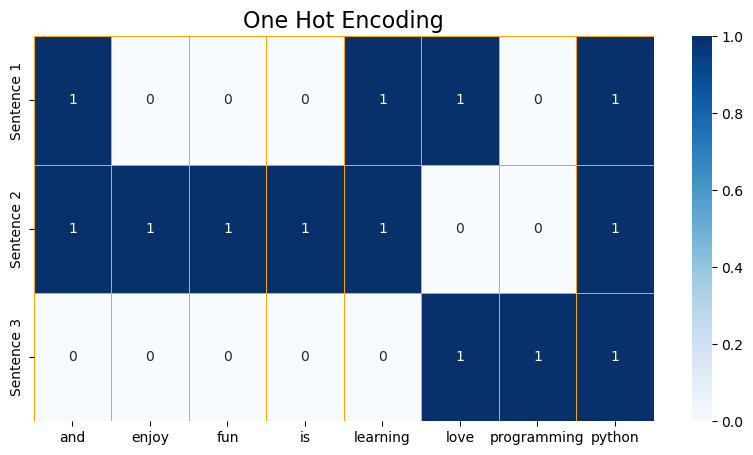

In [23]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentences = [
    "I love learning and I love Python",
    "Python is fun and I enjoy learning",
    "I love Python programming"
]

# One-hot encoding
vectorizer = CountVectorizer(binary=True)
X = vectorizer.fit_transform(sentences)

# Convert to DataFrame for matrix visualization
ohe_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
ohe_df.index = [f"Sentence {i+1}" for i in range(len(sentences))]

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(ohe_df, annot=True, cmap="Blues", cbar=True, linewidths=0.4, linecolor = "orange")
plt.title("One Hot Encoding", fontsize=16)
plt.show()

#### Bag-of-Words (BoW)

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer

# Sample sentences
sentences = [
    "I love learning and I love Python",
    "Python is fun and I enjoy learning",
    "I love Python programming"
]

# Create CountVectorizer
vectorizer = CountVectorizer()

# Fit and transform
X = vectorizer.fit_transform(sentences)

# Convert to DataFrame
bow_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
bow_df.index = [f"Sentence {i+1}" for i in range(len(sentences))]

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(bow_df, annot=True, cmap="YlGnBu", cbar=True, linewidths=0.4, linecolor = "green")
plt.title("Bag of Words Frequency", fontsize=16)
plt.show()

#### N-Gram

In [ ]:
def generate_ngrams(text, n):
    tokens = text.split()
    ngrams = [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]
    return ngrams


text = "The Margherita pizza is not bad taste"

unigrams = generate_ngrams(text, 1)
bigrams = generate_ngrams(text, 2)
trigrams = generate_ngrams(text, 3)

print("Unigrams:", unigrams)
print("Bigrams:", bigrams)
print("Trigrams:", trigrams)

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

sentences1 = [
    "The food is good",
    "The food is not good",
]

# Create bigram vectorizer
vectorizer = CountVectorizer(ngram_range=(3,3))  
X = vectorizer.fit_transform(sentences1)


# Convert to DataFrame for visualization
bigram_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())

# Get unique trigrams (alphabetically)
unique_trigrams = vectorizer.get_feature_names_out()

# Print one per line
print("Unique trigrams (alphabetically):")
for trigram in unique_trigrams:
    print(trigram)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
sns.heatmap(
    bigram_df,
    annot=True,
    cmap="Reds",
    linewidths=0.8,
    linecolor='green'
)
plt.title("a sparse matrix of size (number of sentences × number of grams)")
plt.show()

